In [1]:
import random
import numpy as np


class BasePolicy:
    def __init__(self, env):
        self.env = env

    def select_action(self):
        raise NotImplementedError

    @staticmethod
    def _to_continuous(idx: int, n: int) -> float:
        if n <= 1:
            return 0.0
        return float(2.0 * idx / (n - 1) - 1.0)

    def _build_action(self, node_id, device_id):
        valid_nodes = self.env._get_valid_nodes()
        device_ids = sorted(self.env.devices.keys())

        if len(valid_nodes) == 0 or len(device_ids) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        try:
            node_idx = valid_nodes.index(node_id)
        except ValueError:
            node_idx = 0

        try:
            device_idx = device_ids.index(device_id)
        except ValueError:
            device_idx = 0

        node_signal = self._to_continuous(node_idx, len(valid_nodes))
        device_signal = self._to_continuous(device_idx, len(device_ids))

        return np.array([node_signal, device_signal], dtype=np.float32)

    def _valid_nodes(self):
        return self.env._get_valid_nodes()

    def _device_load(self, device_id):
        return sum(
            1
            for info in self.env.scheduler.node_schedule_info.values()
            if info["device_id"] == device_id
        )

    def _device_finish_time(self, device_id):
        device = self.env.devices[device_id]
        return max(
            (processor.available_time for processor in device.processors),
            default=0.0,
        )


class Random(BasePolicy):
    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        node_id = random.choice(valid_nodes)
        device_id = random.choice(list(self.env.devices.keys()))

        return self._build_action(node_id, device_id)


class Local(BasePolicy):
    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        node_id = valid_nodes[0]

        # نودها از جنس (task_id, node_id) هستند.
        # local یعنی اجرای task روی VE متناظر خودش.
        if isinstance(node_id, tuple):
            task_id, _ = node_id
            device_id = task_id if task_id in self.env.devices else 0
        else:
            device_id = 0

        return self._build_action(node_id, device_id)


class Greedy(BasePolicy):
    def _score(self, node_id, device_id):
        attr = self.env.dag.nodes[node_id]

        cpu_cycles = float(attr["cpu_cycles"])
        compute_power = float(self.env.devices[device_id].compute_power)

        exec_time = cpu_cycles / max(compute_power, 1.0)
        queue_load = float(self._device_load(device_id))
        finish_time = float(self._device_finish_time(device_id))

        # bonus کوچک برای local placement
        local_bonus = 0.0
        if isinstance(node_id, tuple):
            task_id, _ = node_id
            if task_id in self.env.devices and device_id == task_id:
                local_bonus = 0.1

        # هرچه score کمتر باشد بهتر است
        return exec_time + 0.15 * finish_time + 0.05 * queue_load - local_bonus

    def select_action(self):
        valid_nodes = self._valid_nodes()
        if len(valid_nodes) == 0:
            return np.array([0.0, 0.0], dtype=np.float32)

        device_ids = sorted(self.env.devices.keys())

        best_score = float("inf")
        best_node = valid_nodes[0]
        best_device = device_ids[0]

        for node_id in valid_nodes:
            for device_id in device_ids:
                score = self._score(node_id, device_id)
                if score < best_score:
                    best_score = score
                    best_node = node_id
                    best_device = device_id

        return self._build_action(best_node, best_device)

In [2]:
import numpy as np
import pandas as pd

from stable_baselines3 import TD3
from model.dvtp_policy import DVTPPPO

# =========================================================
# helper: single episode runner
# =========================================================

def _run_single_episode(env, agent, max_steps, is_sb3=False):
    obs, _ = env.reset()

    rewards, delays, energies = [], [], []
    success_rates, throughputs = [], []

    terminated = False
    truncated = False
    step_count = 0

    while (not terminated) and (not truncated) and step_count < max_steps:

        # =====================================================
        # action selection
        # =====================================================

        if is_sb3:
            action, _ = agent.predict(obs, deterministic=True)
        else:
            action = agent.select_action()

        # =====================================================
        # environment step
        # =====================================================

        obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(float(info.get("reward", reward)))
        delays.append(float(info.get("delay", 0.0)))
        energies.append(float(info.get("energy", 0.0)))
        success_rates.append(float(info.get("success_rate", 0.0)))
        throughputs.append(float(info.get("throughput", 0.0)))

        step_count += 1

    return {
        "reward": np.sum(rewards),
        "delay": np.sum(delays),
        "energy": np.sum(energies),
        "success_rate": np.mean(success_rates) if len(success_rates) > 0 else 0.0,
        "throughput": np.sum(throughputs),
    }


# =========================================================
# main benchmark
# =========================================================

def evaluate_all_algorithms(
    num_ve,
    num_ves,
    num_nodes,
    max_steps,
    num_learn,
    num_eval_episodes=10,
):

    from env.my_env import VEC

    print("=" * 60)
    print("Benchmark started")
    print("=" * 60)

    # =====================================================
    # TD3 training
    # =====================================================

    # print("\n[1/2] Training TD3...")

    td3_env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)

    td3_model = TD3(
        "MultiInputPolicy",
        td3_env,
        buffer_size=10000,
        batch_size=64,
        verbose=0
    )

    td3_model.learn(total_timesteps=num_learn,progress_bar=True)

    # print("TD3 done")

    # =====================================================
    # DVTPPPO training
    # =====================================================

    # print("\n[2/2] Training DVTPPPO...")

    dvt_env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)

    dvt_model = DVTPPPO(dvt_env)

    dvt_model.learn(num_learn)

    # print("DVTPPPO done")
    # =====================================================
    # algorithms list
    # =====================================================

    algorithms = [
        ("Random", Random, "heuristic"),
        ("Local", Local, "heuristic"),
        ("Greedy", Greedy, "heuristic"),
        ("TD3", td3_model, "sb3"),
        ("DVTPPPO", dvt_model, "sb3"),
    ]

    rows = []

    # =====================================================
    # evaluation loop
    # =====================================================

    for algo_idx, (algo_name, algo, algo_type) in enumerate(algorithms):

        # print("\n" + "-" * 60)
        # print(f"Evaluating {algo_name} ({algo_idx+1}/{len(algorithms)})")
        # print("-" * 60)

        rewards, delays, energies = [], [], []
        success_rates, throughputs = [], []

        for ep in range(num_eval_episodes):

            # print(f"[{algo_name}] Episode {ep+1}/{num_eval_episodes}")

            env = VEC(num_ve=num_ve, num_ves=num_ves, num_nodes=num_nodes)

            # =================================================
            # dispatch policies
            # =================================================

            if algo_type == "heuristic":
                agent = algo(env)
                result = _run_single_episode(env, agent, max_steps, is_sb3=False)

            elif algo_name == "TD3":
                result = _run_single_episode(env, algo, max_steps, is_sb3=True)

            elif algo_name == "DVTPPPO":
                result = _run_single_episode(env, algo, max_steps, is_sb3=True)

            else:
                raise ValueError("Unknown algorithm type")

            rewards.append(result["reward"])
            delays.append(result["delay"])
            energies.append(result["energy"])
            success_rates.append(result["success_rate"])
            throughputs.append(result["throughput"])

            # print(
            #     f"Reward={result['reward']:.3f} | "
            #     f"Delay={result['delay']:.3f} | "
            #     f"Energy={result['energy']:.3f}"
            # )

        row = {
            "algorithm": algo_name,
            "reward": np.mean(rewards),
            "delay": np.mean(delays),
            "energy": np.mean(energies),
            "success_rate": np.mean(success_rates),
            "throughput": np.mean(throughputs),
        }

        rows.append(row)

        # print("\nResult:")
        # print(row)

    print("\n" + "=" * 60)
    print("Benchmark finished")
    print("=" * 60)

    return pd.DataFrame(rows)

In [ ]:
df = evaluate_all_algorithms(

    num_ve=5,
    num_ves=1,
    num_nodes=5,

    max_steps=10,

    num_learn=10,

    num_eval_episodes=1,
)

print(df)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_benchmark_sweep(
    dfs,
    x_values,
    x_label="VE",
    metrics=("reward", "delay", "energy", "success_rate", "throughput"),
    algorithms=None,
):
    """
    dfs: list[pd.DataFrame]
        هر df خروجی evaluate_all_algorithms برای یک مقدار x

    x_values: list
        مثلا [2, 4, 6, 8, 10]

    x_label: str
        نام محور x (مثل VE یا num_nodes)

    metrics: tuple
        متریک‌هایی که رسم می‌شوند

    algorithms: list[str] or None
        اگر None باشد از اولین df استخراج می‌شود
    """

    if algorithms is None:
        algorithms = dfs[0]["algorithm"].tolist()

    # ساخت lookup سریع
    def get_value(df, algo, metric):
        row = df[df["algorithm"] == algo]
        if len(row) == 0:
            return np.nan
        return row.iloc[0][metric]

    # =====================================================
    # برای هر metric یک نمودار جدا
    # =====================================================

    for metric in metrics:

        plt.figure(figsize=(7, 5))

        for algo in algorithms:

            y = [
                get_value(df, algo, metric)
                for df in dfs
            ]

            plt.plot(
                x_values,
                y,
                marker="o",
                linewidth=2,
                label=algo,
            )

        plt.xlabel(x_label)
        plt.ylabel(metric)
        plt.title(f"{metric} vs {x_label}")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
ve_list = [2, 4]

dfs = []

for ve in ve_list:
    df = evaluate_all_algorithms(
        num_ve=ve,
        num_ves=1,
        num_nodes=5,
        max_steps=10,
        num_learn=10,
        num_eval_episodes=1,
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ve_list,
    x_label="Number of Vehicles"
)

# -----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# FINAL EXPERIMENTS

Output()

Benchmark started


Output()


Benchmark finished
Benchmark started


Output()


Benchmark finished
Benchmark started


Output()


Benchmark finished
Benchmark started



Benchmark finished


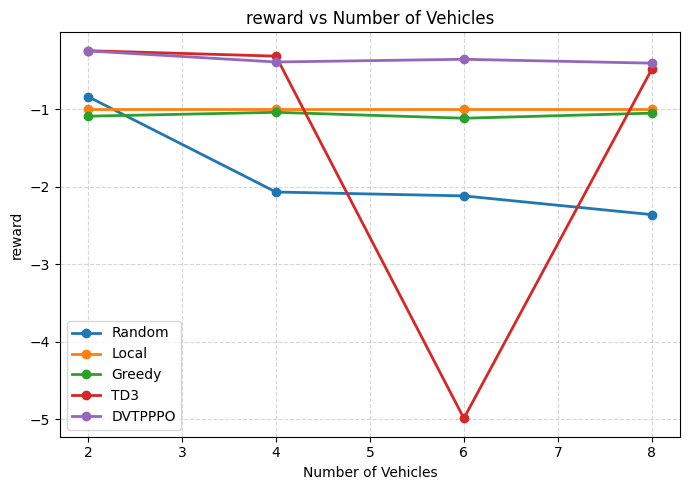

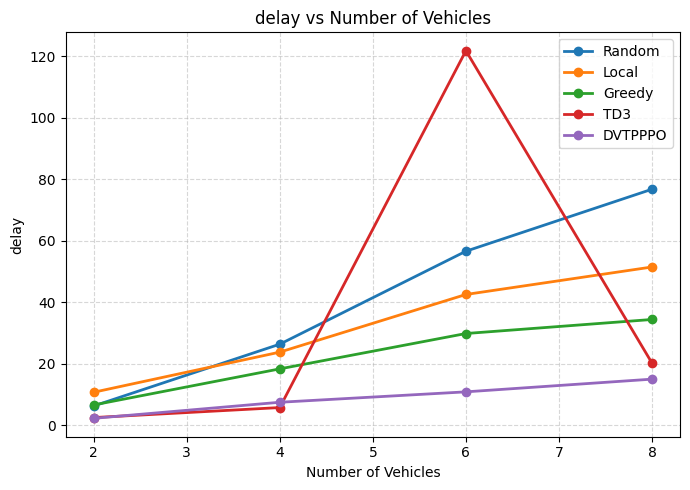

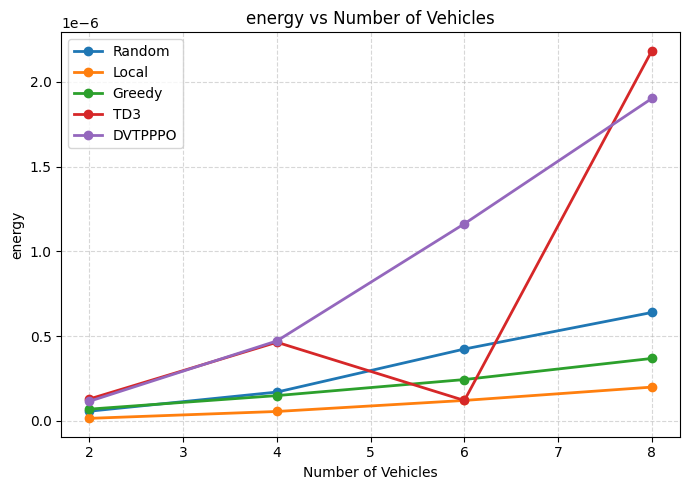

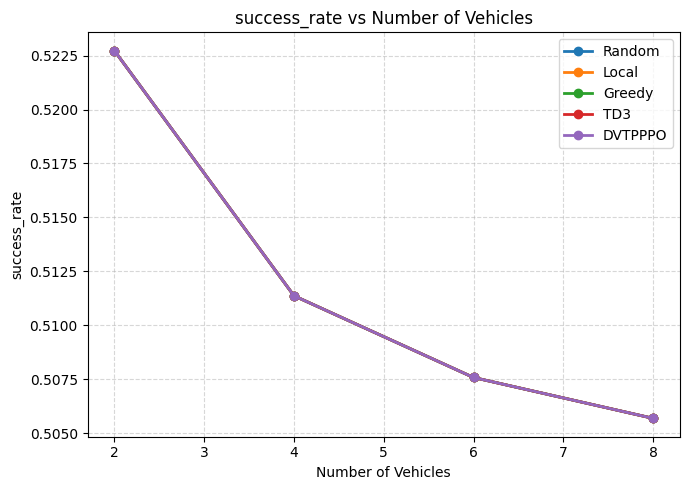

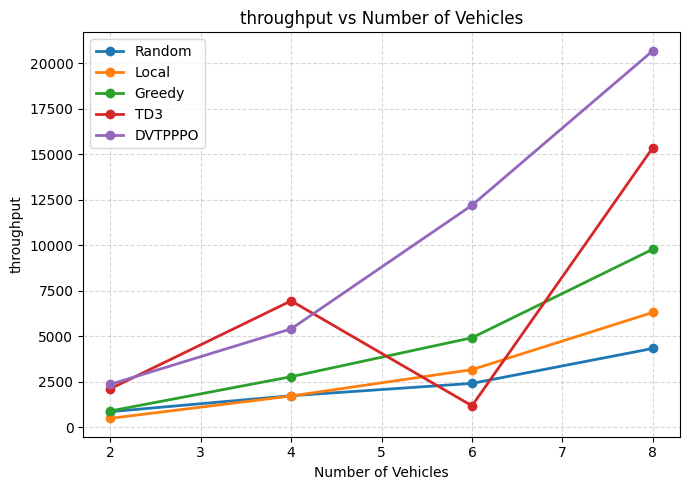

In [4]:
ve_list = [2, 4, 6, 8]

dfs = []

for ve in ve_list:
    df = evaluate_all_algorithms(
        num_ve=ve,
        num_ves=2,
        num_nodes=10,
        max_steps=30_000,
        num_learn=30_000,
        num_eval_episodes=1,
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ve_list,
    x_label="Number of Vehicles"
)

In [ ]:
ves_list = [1, 2, 3, 4]

dfs = []

for ves in ves_list:
    df = evaluate_all_algorithms(
        num_ve=5,
        num_ves=ves,
        num_nodes=5,
        max_steps=10000,
        num_learn=10000,
        num_eval_episodes=1,
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ves_list,
    x_label="Number of Servers"
)

In [ ]:
plot_benchmark_sweep(
    dfs=dfs,
    x_values=ves_list,
    x_label="Number of Servers"
)

In [ ]:
tasks_list = [5, 10, 15, 20]

dfs = []

for task in tasks_list:
    df = evaluate_all_algorithms(
        num_ve=5,
        num_ves=2,
        num_nodes=task,
        max_steps=2000,
        num_learn=2000,
        num_eval_episodes=1,
    )
    dfs.append(df)

plot_benchmark_sweep(
    dfs=dfs,
    x_values=ve_list,
    x_label="Number of Tasks"
)